# Analysis of the **_results_**

### **Setup**

In [28]:
!git clone https://github.com/pante31/LLM_Creativity.git

fatal: destination path 'LLM_Creativity' already exists and is not an empty directory.


In [29]:
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from math import pi
from scipy.stats import mannwhitneyu
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA, FactorAnalysis
from sklearn.preprocessing import StandardScaler
from scipy.stats import kendalltau


### Loading **results**

In [30]:
current_path = os.getcwd()
results_file = current_path + '/LLM_Creativity/creativity_metrics.json'
human_scores_file = current_path + '/LLM_Creativity/texts_evaluation_sheet.xlsx'

with open(results_file, 'r') as f:
    results = json.load(f)

In [31]:
metrics = list(results.keys())

human_scores_df = pd.read_excel(human_scores_file)
results_df = pd.DataFrame(columns=metrics)
results_df.head()

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge


In [32]:
human_scores_df.head()

,timestamp,session_id,native_languge,gender,age,education,experience,text_id,txt_language,author,...,effectiveness,elaboration,fluency,flexibility,novelty,originality,surprise,usefulness,value,creativity
0,2026-01-25 18:50:38,1.769367e+09,Italian,Male,24,Master's Degree,"If not daily, almost",360,it,DeepSeek-V3.2,...,4,2,5,4,1,1,2,4,2,3
1,2026-01-25 19:55:13,1.769371e+09,Italian,Male,26,Bachelor's Degree,"If not daily, almost",201,it,GPT-5.2,...,4,5,5,4,1,1,2,2,3,4
2,2026-01-25 19:57:26,1.769371e+09,Italian,Male,26,Bachelor's Degree,"If not daily, almost",331,it,DeepSeek-V3.2,...,4,3,5,4,2,3,2,1,2,4
3,2026-01-25 20:05:30,1.769371e+09,Italian,Male,24,Bachelor's Degree,"If not daily, almost",62,it,human,...,4,5,3,1,2,3,4,5,4,4
4,2026-01-25 20:06:14,1.769371e+09,Italian,Male,24,Bachelor's Degree,"If not daily, almost",96,it,human,...,4,5,3,1,2,3,4,5,4,4


## **_Creativity Index_**

In [33]:
creativity_index = results['creativity_index']
results_df.creativity_index = creativity_index
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,6.353383,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6.778182,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,5.734694,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.703476,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6.744565,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,5.920341,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,5.884507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,5.747521,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,6.995062,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## **_Perplexity_**

In [34]:
perplexity = results['perplexity']
results_df.perplexity = perplexity
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,23.616358,NaN,NaN,NaN,NaN,NaN,NaN
1,6.353383,9.427574,NaN,NaN,NaN,NaN,NaN,NaN
2,6.778182,11.088195,NaN,NaN,NaN,NaN,NaN,NaN
3,5.734694,8.420053,NaN,NaN,NaN,NaN,NaN,NaN
4,5.703476,19.137821,NaN,NaN,NaN,NaN,NaN,NaN
5,6.744565,12.470201,NaN,NaN,NaN,NaN,NaN,NaN
6,5.920341,10.507423,NaN,NaN,NaN,NaN,NaN,NaN
7,5.884507,8.487293,NaN,NaN,NaN,NaN,NaN,NaN
8,5.747521,11.037381,NaN,NaN,NaN,NaN,NaN,NaN
9,6.995062,8.598725,NaN,NaN,NaN,NaN,NaN,NaN


## **_CR-POS_**

In [35]:
cr_pos = results['cr_pos']
results_df.cr_pos = cr_pos
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,23.616358,5.892,NaN,NaN,NaN,NaN,NaN
1,6.353383,9.427574,7.877,NaN,NaN,NaN,NaN,NaN
2,6.778182,11.088195,5.510,NaN,NaN,NaN,NaN,NaN
3,5.734694,8.420053,6.989,NaN,NaN,NaN,NaN,NaN
4,5.703476,19.137821,5.335,NaN,NaN,NaN,NaN,NaN
5,6.744565,12.470201,7.219,NaN,NaN,NaN,NaN,NaN
6,5.920341,10.507423,5.899,NaN,NaN,NaN,NaN,NaN
7,5.884507,8.487293,7.361,NaN,NaN,NaN,NaN,NaN
8,5.747521,11.037381,6.313,NaN,NaN,NaN,NaN,NaN
9,6.995062,8.598725,8.693,NaN,NaN,NaN,NaN,NaN


## **_Template Rate_**

In [36]:
template_rate = results['template_rate']
results_df.template_rate = template_rate
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,23.616358,5.892,0.479070,NaN,NaN,NaN,NaN
1,6.353383,9.427574,7.877,0.099057,NaN,NaN,NaN,NaN
2,6.778182,11.088195,5.510,0.435737,NaN,NaN,NaN,NaN
3,5.734694,8.420053,6.989,0.214400,NaN,NaN,NaN,NaN
4,5.703476,19.137821,5.335,0.325540,NaN,NaN,NaN,NaN
5,6.744565,12.470201,7.219,0.075901,NaN,NaN,NaN,NaN
6,5.920341,10.507423,5.899,0.203498,NaN,NaN,NaN,NaN
7,5.884507,8.487293,7.361,0.313531,NaN,NaN,NaN,NaN
8,5.747521,11.037381,6.313,0.463992,NaN,NaN,NaN,NaN
9,6.995062,8.598725,8.693,0.615628,NaN,NaN,NaN,NaN


## **_Tempalte-per-token_**

In [37]:
template_per_token = results['template_per_token']
results_df.template_per_token = template_per_token
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,23.616358,5.892,0.479070,0.862016,NaN,NaN,NaN
1,6.353383,9.427574,7.877,0.099057,0.119497,NaN,NaN,NaN
2,6.778182,11.088195,5.510,0.435737,0.783699,NaN,NaN,NaN
3,5.734694,8.420053,6.989,0.214400,0.268800,NaN,NaN,NaN
4,5.703476,19.137821,5.335,0.325540,0.611511,NaN,NaN,NaN
5,6.744565,12.470201,7.219,0.075901,0.091082,NaN,NaN,NaN
6,5.920341,10.507423,5.899,0.203498,0.368839,NaN,NaN,NaN
7,5.884507,8.487293,7.361,0.313531,0.475248,NaN,NaN,NaN
8,5.747521,11.037381,6.313,0.463992,0.847737,NaN,NaN,NaN
9,6.995062,8.598725,8.693,0.615628,1.199578,NaN,NaN,NaN


## **_Expectation Adjusted Distinct (EAD)_**

In [38]:
ead = results['ead']
results_df.ead = ead
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,NaN,NaN
1,6.353383,9.427574,7.877,0.099057,0.119497,0.526765,NaN,NaN
2,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,NaN,NaN
3,5.734694,8.420053,6.989,0.214400,0.268800,0.448493,NaN,NaN
4,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,NaN,NaN
5,6.744565,12.470201,7.219,0.075901,0.091082,0.536654,NaN,NaN
6,5.920341,10.507423,5.899,0.203498,0.368839,0.355574,NaN,NaN
7,5.884507,8.487293,7.361,0.313531,0.475248,0.417317,NaN,NaN
8,5.747521,11.037381,6.313,0.463992,0.847737,0.378316,NaN,NaN
9,6.995062,8.598725,8.693,0.615628,1.199578,0.444025,NaN,NaN


## **_SBERT Diversity_**

In [39]:
sbert_diversity = results['sbert_diversity']
results_df.sbert_diversity = sbert_diversity
results_df.head(10)

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_as_a_judge
0,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,0.791343,NaN
1,6.353383,9.427574,7.877,0.099057,0.119497,0.526765,0.521430,NaN
2,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,0.813438,NaN
3,5.734694,8.420053,6.989,0.214400,0.268800,0.448493,0.642695,NaN
4,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,0.794141,NaN
5,6.744565,12.470201,7.219,0.075901,0.091082,0.536654,0.537325,NaN
6,5.920341,10.507423,5.899,0.203498,0.368839,0.355574,0.717927,NaN
7,5.884507,8.487293,7.361,0.313531,0.475248,0.417317,0.571284,NaN
8,5.747521,11.037381,6.313,0.463992,0.847737,0.378316,0.851537,NaN
9,6.995062,8.598725,8.693,0.615628,1.199578,0.444025,0.613979,NaN


## **_LLM-as-a-judge_**

In [40]:
len(results['llm_as_a_judge'])

4400

In [41]:
llm_as_a_judge = results['llm_as_a_judge']
evaluation_metrics = ['authenticity', 'effectiveness', 'elaboration', 'fluency', 'flexibility', 'novelty', 'originality', 'surprise', 'usefulness', 'value', 'creativity']
evaluation_metrics = ["surprise", "novelty", "value", "authenticity", "originality", "effectiveness", "fluency", "flexibility", "elaboration", "usefulness", "creativity"]
llm_as_a_judge_metrics_name = ["llm_" + evaluation_metrics[i] for i in range(len(evaluation_metrics))]

results_df.drop("llm_as_a_judge", axis=1, inplace=True)

In [42]:
results_df.head()

,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity
0,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,0.791343
1,6.353383,9.427574,7.877,0.099057,0.119497,0.526765,0.521430
2,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,0.813438
3,5.734694,8.420053,6.989,0.214400,0.268800,0.448493,0.642695
4,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,0.794141


In [43]:
llm_as_a_judge_dictionary = {}

for j in range(len(evaluation_metrics)):
    metric_list = []
    for i in range(len(llm_as_a_judge)//len(evaluation_metrics)):
        try:
            metric_list.append(llm_as_a_judge[i*len(evaluation_metrics)+j][evaluation_metrics[j]]['score'])
        except TypeError:
            metric_list.append(-1)
    llm_as_a_judge_dictionary[evaluation_metrics[j]] = metric_list
    results_df[llm_as_a_judge_metrics_name[j]] = llm_as_a_judge_dictionary[evaluation_metrics[j]]

In [44]:
# adding "source" for each text
results_df.insert(0, "source", ["human"]*(len(results_df)//2)+["LLM"]*(len(results_df)//2))

# keeping only scores for english texts - selects every second row (0, 2, 4, 6...)
results_df = results_df.iloc[::2]
results_df = results_df.reset_index(drop=True)

In [45]:
results_df.head()

,source,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_surprise,llm_novelty,llm_value,llm_authenticity,llm_originality,llm_effectiveness,llm_fluency,llm_flexibility,llm_elaboration,llm_usefulness,llm_creativity
0,human,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,0.791343,5,5,5,5,5,5,4,5,5,1,5
1,human,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,0.813438,5,5,5,4,5,5,5,4,5,5,5
2,human,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,0.794141,5,5,4,5,5,5,4,5,5,1,5
3,human,5.920341,10.507423,5.899,0.203498,0.368839,0.355574,0.717927,5,5,5,5,5,5,4,5,5,1,5
4,human,5.747521,11.037381,6.313,0.463992,0.847737,0.378316,0.851537,5,5,5,5,5,5,5,5,5,5,5


## **_Human Evaluation_**

In [46]:
evaluation_metrics = ['authenticity', 'effectiveness', 'elaboration', 'fluency', 'flexibility', 'novelty', 'originality', 'surprise', 'usefulness', 'value', 'creativity']
human_metrics_name = ["human_" + evaluation_metrics[i] for i in range(len(evaluation_metrics))]

In [47]:
human_metrics_name

['human_authenticity',
 'human_effectiveness',
 'human_elaboration',
 'human_fluency',
 'human_flexibility',
 'human_novelty',
 'human_originality',
 'human_surprise',
 'human_usefulness',
 'human_value',
 'human_creativity']

### Score Aggregation

In [48]:
# 1. Force all metric columns to be numeric 
for col in evaluation_metrics:
    human_scores_df[col] = pd.to_numeric(human_scores_df[col], errors='coerce')

# 3. Correct Story ID
# By dividing by 2 and rounding up, ID 1 & 2 become 1. ID 3 & 4 become 2. ID 399 & 400 become 200.
human_scores_df['story_id'] = np.ceil(human_scores_df['text_id'] / 2).astype(int)

# 4. Define how we want to aggregate the data
# We want the mathematical mean for the scores, and we just keep the 'first' author label
agg_dict = {metric: 'mean' for metric in evaluation_metrics}
agg_dict['author'] = 'first' 

# 5. Group by the new 'story_id' and apply the aggregation
aggregated_human_df = human_scores_df.groupby('story_id').agg(agg_dict).reset_index()

# Optional: Rename 'author' to 'source' to perfectly match your earlier SciPy/Seaborn scripts!
aggregated_human_df.rename(columns={'author': 'source'}, inplace=True)

# Check the results
print(f"Final dataset length: {len(aggregated_human_df)} texts")
aggregated_human_df.columns = ["story_id"]+human_metrics_name+["source"]
aggregated_human_df.head()

Final dataset length: 165 texts


,story_id,human_authenticity,human_effectiveness,human_elaboration,human_fluency,human_flexibility,human_novelty,human_originality,human_surprise,human_usefulness,human_value,human_creativity,source
0,2,3.0,4.0,4.0,3.0,4.0,3.0,3.0,4.0,4.0,3.0,4.0,human
1,3,2.0,1.5,2.5,1.5,2.5,1.5,1.0,2.5,2.0,1.0,2.5,human
2,4,3.0,3.8,2.8,2.8,3.6,3.6,3.8,3.8,3.8,3.6,4.0,human
3,5,3.5,3.0,4.0,4.5,4.0,3.0,2.5,3.5,3.0,2.0,3.5,human
4,6,4.0,4.0,4.5,4.0,4.0,3.5,4.5,4.5,3.0,5.0,5.0,human


### Adding missing score values

In [49]:
# 1. Set the 'story_id' as the index of the dataframe
aggregated_human_df.set_index('story_id', inplace=True)

# 2. Force the dataframe to have exactly rows 1 through 200
# Any missing stories will be created as empty rows (NaNs)
aggregated_human_df = aggregated_human_df.reindex(range(1, 201))

# 3. Fill missing values with 3 ONLY for the subjective metrics
aggregated_human_df[human_metrics_name] = aggregated_human_df[human_metrics_name].fillna(3.0)

# 4. Reset the index so 'story_id' becomes a normal column again
aggregated_human_df.reset_index(names='story_id', inplace=True)

print(f"Final dataset length: {len(aggregated_human_df)} texts")
aggregated_human_df.head()

Final dataset length: 200 texts


,story_id,human_authenticity,human_effectiveness,human_elaboration,human_fluency,human_flexibility,human_novelty,human_originality,human_surprise,human_usefulness,human_value,human_creativity,source
0,1,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN
1,2,3.0,4.0,4.0,3.0,4.0,3.0,3.0,4.0,4.0,3.0,4.0,human
2,3,2.0,1.5,2.5,1.5,2.5,1.5,1.0,2.5,2.0,1.0,2.5,human
3,4,3.0,3.8,2.8,2.8,3.6,3.6,3.8,3.8,3.8,3.6,4.0,human
4,5,3.5,3.0,4.0,4.5,4.0,3.0,2.5,3.5,3.0,2.0,3.5,human


## **Complete DataFrame**

In [50]:
results_df.head()

,source,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_surprise,llm_novelty,llm_value,llm_authenticity,llm_originality,llm_effectiveness,llm_fluency,llm_flexibility,llm_elaboration,llm_usefulness,llm_creativity
0,human,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,0.791343,5,5,5,5,5,5,4,5,5,1,5
1,human,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,0.813438,5,5,5,4,5,5,5,4,5,5,5
2,human,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,0.794141,5,5,4,5,5,5,4,5,5,1,5
3,human,5.920341,10.507423,5.899,0.203498,0.368839,0.355574,0.717927,5,5,5,5,5,5,4,5,5,1,5
4,human,5.747521,11.037381,6.313,0.463992,0.847737,0.378316,0.851537,5,5,5,5,5,5,5,5,5,5,5


In [51]:
final_df = pd.concat([results_df, aggregated_human_df], axis=1)
final_df = final_df.iloc[:, :-1]
final_df = final_df.set_index('story_id')
final_df.head()

,source,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_surprise,llm_novelty,...,human_effectiveness,human_elaboration,human_fluency,human_flexibility,human_novelty,human_originality,human_surprise,human_usefulness,human_value,human_creativity
story_id,,,,,,,,,,,,,,,,,,,,,
1,human,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,0.791343,5,5,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
2,human,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,0.813438,5,5,...,4.0,4.0,3.0,4.0,3.0,3.0,4.0,4.0,3.0,4.0
3,human,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,0.794141,5,5,...,1.5,2.5,1.5,2.5,1.5,1.0,2.5,2.0,1.0,2.5
4,human,5.920341,10.507423,5.899,0.203498,0.368839,0.355574,0.717927,5,5,...,3.8,2.8,2.8,3.6,3.6,3.8,3.8,3.8,3.6,4.0
5,human,5.747521,11.037381,6.313,0.463992,0.847737,0.378316,0.851537,5,5,...,3.0,4.0,4.5,4.0,3.0,2.5,3.5,3.0,2.0,3.5


### **LLM-as-a-judge**: ***Creativity***

Evaluate the explainations for the ***creativity*** metric

In [52]:
creativity_list = [llm_as_a_judge[11*i+10] for i in range(len(llm_as_a_judge)//len(llm_as_a_judge_metrics_name))]
creativity_list[0:5]

[{'creativity': {'score': 5,
   'justification': 'Unique blend of philosophical and sci-fi elements',
   'excerpt': 'Even by achieving immortality, death, is inescapable'}},
 {'creativity': {'score': 5,
   'justification': 'Unique blend of philosophical and sci-fi elements',
   'excerpt': "Anche ottenendo l'immortalità, la morte è ineluttabile"}},
 {'creativity': {'score': 5,
   'justification': 'Unique blend of sci-fi and humor',
   'excerpt': 'A giant human face'}},
 {'creativity': {'score': 5,
   'justification': 'Unique blend of sci-fi elements',
   'excerpt': 'Un gigante volto umano'}},
 {'creativity': {'score': 5,
   'justification': 'Unique blend of humor and horror',
   'excerpt': "he looks more like there wasn't something right"}}]

# **<u>Results review:**</u>

## **<u>RQ1:</u> _Comparative Analysis (Human vs. AI)_**

### **The Mann-Whitney U test**
The **Mann-Whitney U test** is a nonparametric test of the null hypothesis that the distribution underlying sample $x$ is the same as the distribution underlying sample $y$. It is often used as a test of difference in location between distributions.

In [53]:
def run_comparative_analysis(df, metrics, group_col='source', human_label='human', ai_label='LLM'):
    """
    Runs the Mann-Whitney U Test for a list of metrics between Human and AI texts.
    """
    results = []
    
    for metric in metrics:
        # isolate the two groups
        human_raw = df[df[group_col] == human_label][metric]
        ai_raw = df[df[group_col] == ai_label][metric]
        
        # turns strings like "4" into int 4, and garbage into NaN
        human_numeric = pd.to_numeric(human_raw, errors='coerce')
        ai_numeric = pd.to_numeric(ai_raw, errors='coerce')
        
        # drop NaNs AND drop -1 error codes
        human_scores = human_numeric[(human_numeric.notna()) & (human_numeric != -1)]
        ai_scores = ai_numeric[(ai_numeric.notna()) & (ai_numeric != -1)]
        
        # Run Mann-Whitney U Test (two-sided = we check for ANY difference)
        u_stat, p_value = mannwhitneyu(human_scores, ai_scores, alternative='two-sided')

        # SciPy returns U1 --> U1 + U2 = n1 * n2
        n1 = len(human_scores)
        n2 = len(ai_scores)
        u2 = n1 * n2 - u_stat
        
        u_final = min(u_stat, u2)
        
        # significance based on alpha = 0.05
        is_significant = "Yes" if p_value < 0.05 else "No"
        
        human_mean = human_scores.mean()
        ai_mean = ai_scores.mean()
        
        results.append({
            'Metric': metric,
            'Human Mean': round(human_mean, 3),
            'AI Mean': round(ai_mean, 3),
            'U-Statistic': u_final,
            'p-value': p_value,
            'Significant (alpha=0.05)': is_significant
        })
        
    results_df = pd.DataFrame(results)
    return results_df

In [54]:
metrics = list(final_df.columns.values)
metrics.remove("source")
mw_results = run_comparative_analysis(final_df, metrics)
print(mw_results)

                 Metric  Human Mean  AI Mean  U-Statistic       p-value  \
0      creativity_index       6.135    6.119       4987.0  9.756345e-01   
1            perplexity      16.196   11.268       2493.0  9.105212e-10   
2                cr_pos       5.561    5.657       4710.0  4.793411e-01   
3         template_rate       0.448    0.509       3040.0  1.686023e-06   
4    template_per_token       0.940    1.054       3516.0  2.892216e-04   
5                   ead       0.450    0.505       2576.0  3.189156e-09   
6       sbert_diversity       0.794    0.804       4609.0  3.400111e-01   
7          llm_surprise       4.780    4.900       4460.0  1.314462e-02   
8           llm_novelty       4.200    4.900       2914.0  1.169351e-10   
9             llm_value       4.650    5.000       3450.0  1.593141e-09   
10     llm_authenticity       4.420    4.970       3065.5  1.751517e-11   
11      llm_originality       4.710    5.000       3750.0  1.002813e-07   
12    llm_effectiveness  

### **Box-plots**
We use **box-plots** to see the distribution spread.

In [55]:
def plot_distributions(df, metrics, group_col='source', human_label='human', ai_label='LLM'):
    """
    Generates side-by-side boxplots for Human vs AI for each metric.
    """
    num_metrics = len(metrics)
    fig, axes = plt.subplots(nrows=(num_metrics // 3) + 1, ncols=3, figsize=(15, 5 * ((num_metrics // 3) + 1)))
    axes = axes.flatten()
    
    sns.set_theme(style="whitegrid")
    palette = {human_label: "#4C72B0", ai_label: "#55A868"}

    for i, metric in enumerate(metrics):
        sns.boxplot(
            data=df, 
            x=group_col, 
            y=metric, 
            ax=axes[i], 
            palette=palette,
            width=0.5
        )
        axes[i].set_title(f'Distribution of {metric}', fontsize=12, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Score')

    # remove empty subplots if metrics don't perfectly fill the grid
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.savefig('comparative_boxplots.pdf', format='pdf', dpi=300) # Save high-res for LaTeX
    plt.show()

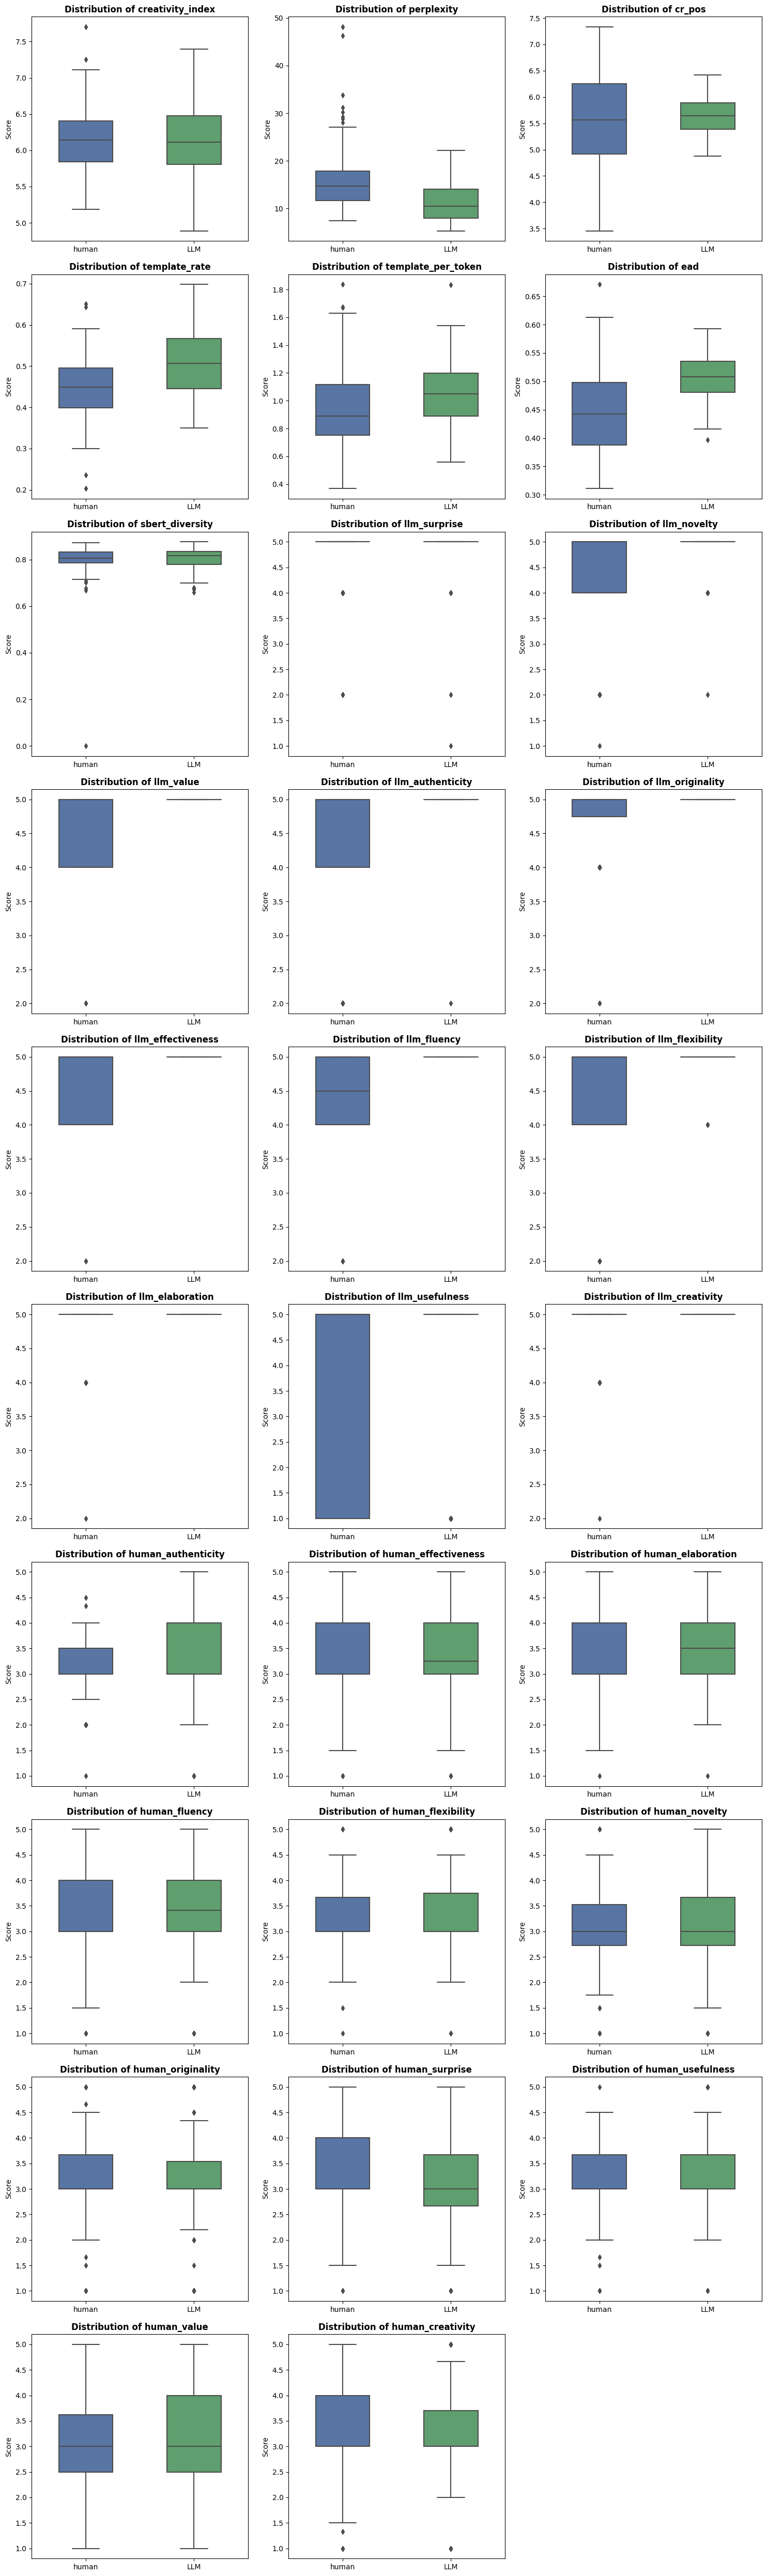

In [56]:
plot_distributions(final_df, metrics)

### **Radar charts**
We employ **radar charts** to compare the multi-dimensional profiles of the subjective and automated metrics

In [57]:
def plot_radar_chart(df, metrics, group_col='source', title="Subjective Evaluation Profile", human_label='human', ai_label='LLM'):
    """
    Generates a radar chart comparing the mean scores of Human vs AI.
    Best used for Likert scale data (1 to 5).
    """
    # mean for each group
    group_means = df.groupby(group_col)[metrics].mean()
    
    # set up the angles for the radar chart
    N = len(metrics)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1] # Close the loop
    
    # initialize the plot
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    # draw one axis per variable and add labels
    plt.xticks(angles[:-1], metrics, size=10, fontweight='bold')
    
    # set Y-axis limits if using 1-5 Likert scale
    ax.set_ylim(1, 5)
    ax.set_yticks([2, 3, 4, 5])
    ax.set_yticklabels(["2", "3", "4", "5"], color="grey", size=8)

    human_values = group_means.loc[human_label].values.flatten().tolist()
    human_values += human_values[:1]
    ax.plot(angles, human_values, linewidth=2, linestyle='solid', label=human_label, color='#4C72B0')
    ax.fill(angles, human_values, '#4C72B0', alpha=0.1)

    ai_values = group_means.loc[ai_label].values.flatten().tolist()
    ai_values += ai_values[:1]
    ax.plot(angles, ai_values, linewidth=2, linestyle='solid', label=ai_label, color='#55A868')
    ax.fill(angles, ai_values, '#55A868', alpha=0.1)

    plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
    plt.title(title, size=14, fontweight='bold', y=1.05)
    
    plt.tight_layout()
    plt.savefig('radar_chart_profile.pdf', format='pdf', dpi=300)
    plt.show()

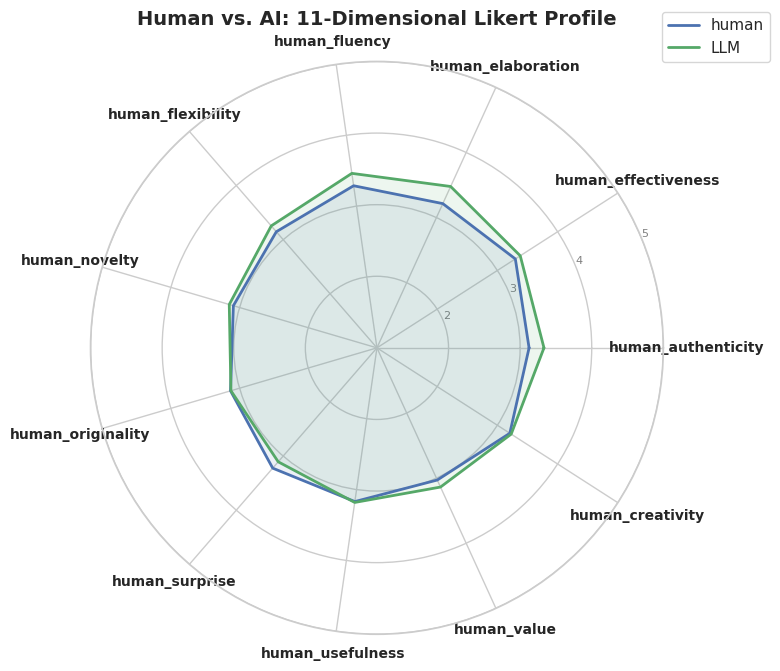

In [58]:
plot_radar_chart(final_df, human_metrics_name, title="Human vs. AI: 11-Dimensional Likert Profile")

## **<u>RQ2:</u> _Correlation Analysis (Metric Validation)_**

### **Spearman's Rank Correlation Coefficient ($\rho$)**
We use **Spearman's Rank Correlation Coefficient** between:
1. The _objective scores_ (e.g., L-Uniqueness, Perplexity, Template Rate).
2. The _aggregated human ratings_ for relevant dimensions (e.g., Novelty, Creativity).

<u>Method of correlation:</u>
- **pearson** : standard correlation coefficient
    - It is correlation coefficient that measures **_linear correlation_** between two sets of data.
- **spearman** : Spearman rank correlation
    - It is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated. Used for **_non-linear correlations_**.


> Do we need to **normalize data** before analyzing them?
- **_Min-Max Normalization_(scaling between 0 and 1)** with `MinMaxScaler()`
    - `df['normalized'] = (df['values'] - df['values'].min()) / (df['values'].max() - df['values'].min())`
- **_Standardization_ (in case of outliers)** with `StandardScaler()`
    - It transforms your data such that it has a _mean_ of **0** and a _standard deviation_ of **1**.

In [59]:
objective_metrics = ['creativity_index','perplexity','cr_pos','template_rate','template_per_token','ead','sbert_diversity']
objective_scores = final_df[objective_metrics].copy()

aggregated_human_ratings = final_df[human_metrics_name].copy()

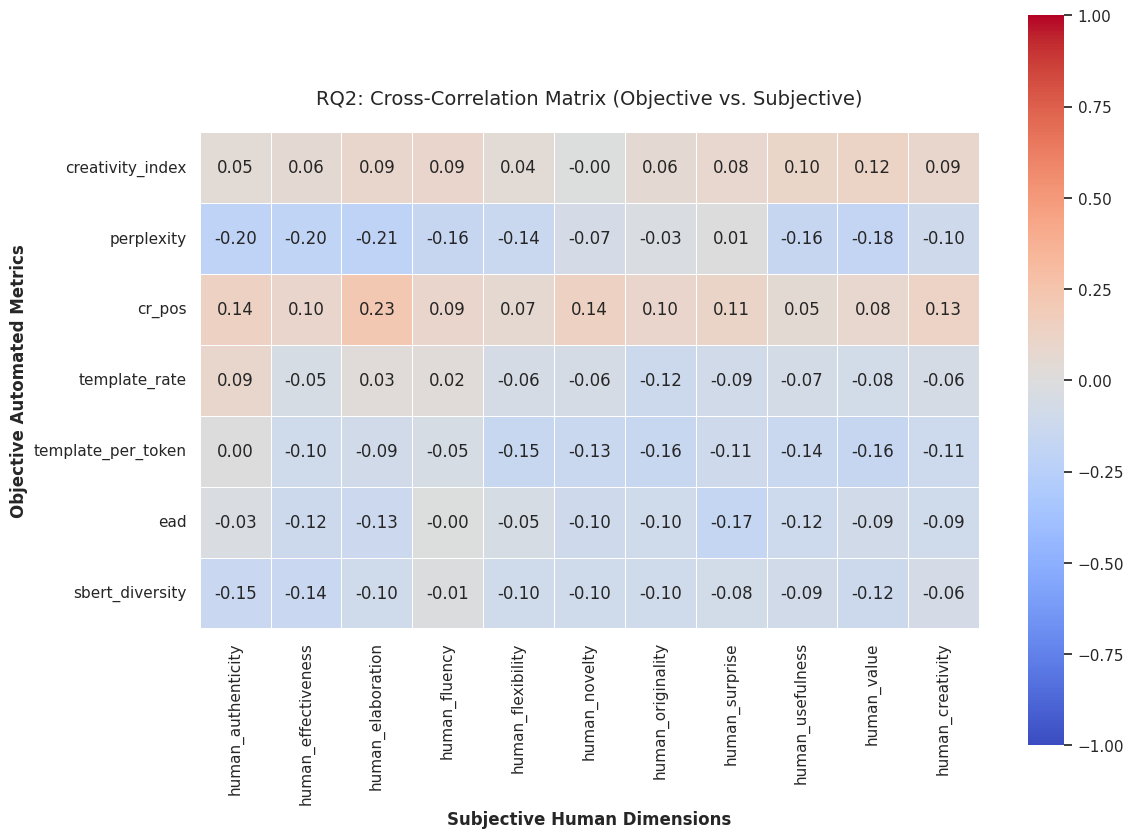

In [60]:
# Spearman rank correlation
correlation_df = pd.concat([objective_scores, aggregated_human_ratings], axis=1)
corr = correlation_df.corr(method='spearman')
cross_corr = corr.loc[objective_metrics, human_metrics_name] # we only consider automated metrics vs. human scores

plt.figure(figsize=(12, 10))

# Added vmin=-1 and vmax=1 to lock the color scale, and fmt=".2f" to clean up numbers
sns.heatmap(
    cross_corr, 
    annot=True, 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    fmt=".2f", 
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title("RQ2: Cross-Correlation Matrix (Objective vs. Subjective)", fontsize=14, pad=20)
plt.ylabel("Objective Automated Metrics", fontweight='bold')
plt.xlabel("Subjective Human Dimensions", fontweight='bold')
plt.tight_layout()

# Save as PDF for high-quality LaTeX rendering
plt.savefig('rq2_correlation_heatmap.pdf', format='pdf', dpi=300) 
plt.show()

## **<u>RQ3:</u> _LLM-as-a-judge Reliability Assessment_**

### **Kendall's $\tau_b$**
**Kendall’s $\tau_b$** is a non-parametric statistic that measures the number of concordant and discordant
pairs between two lists. Conceptually, instead of comparing absolute scores (e.g., “Did they both give
a 5? ”), this metric asks: “Do they agree on which story is BETTER? ”. It achieves this by inspecting
every possible pair of stories in the dataset.

In [67]:
def assess_llm_reliability(df, subjective_metrics, human_prefix='human_', llm_prefix='llm_'):
    """
    Computes Kendall's Tau-b between Human and LLM evaluations for paired texts.
    """
    results = []
    
    for metric in subjective_metrics:
        human_col = f"{human_prefix}{metric}"
        llm_col = f"{llm_prefix}{metric}"
        
        # 1. Check if columns exist
        if human_col not in df.columns or llm_col not in df.columns:
            print(f"Skipping {metric}: Missing columns in DataFrame.")
            continue
            
        # 2. Extract the paired columns
        paired_data = df[[human_col, llm_col]].copy()
        
        # 3. Force numeric and clean data (Crucial: drop NaNs and our -1 error codes)
        paired_data[human_col] = pd.to_numeric(paired_data[human_col], errors='coerce')
        paired_data[llm_col] = pd.to_numeric(paired_data[llm_col], errors='coerce')
        
        # Filter out rows where either the Human or LLM score is missing or invalid (-1)
        valid_data = paired_data[
            (paired_data[human_col].notna()) & 
            (paired_data[llm_col].notna()) & 
            (paired_data[human_col] != -1) & 
            (paired_data[llm_col] != -1)
        ]
        
        if len(valid_data) < 10:
            print(f"Skipping {metric}: Insufficient valid paired data (n={len(valid_data)}).")
            continue
            
        # 4. Compute Kendall's Tau-b
        # scipy's kendalltau computes tau-b by default
        tau_b, p_value = kendalltau(valid_data[human_col], valid_data[llm_col])
        
        is_significant = "Yes" if p_value < 0.05 else "No"
        
        results.append({
            'Metric': metric.capitalize(),
            'Valid Pairs (n)': len(valid_data),
            'Kendall Tau-b': round(tau_b, 3),
            'p-value': p_value,
            'Significant (alpha=0.05)': is_significant
        })
        
    # Sort by strongest agreement to weakest
    results_df = pd.DataFrame(results).sort_values(by='Kendall Tau-b', ascending=False).reset_index(drop=True)
    return results_df

In [68]:
def plot_llm_reliability(tau_df):
    """
    Creates a horizontal bar chart of Kendall's Tau-b scores.
    """
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # Create bar plot
    ax = sns.barplot(
        data=tau_df, 
        x='Kendall Tau-b', 
        y='Metric', 
        palette='viridis' # A nice academic color palette
    )
    
    # Add vertical lines to show threshold of "moderate" and "strong" agreement
    ax.axvline(0.3, color='gray', linestyle='--', alpha=0.7, label='Moderate Agreement (>0.3)')
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.7, label='Strong Agreement (>0.5)')
    
    # Add the exact numbers at the end of each bar
    for p in ax.patches:
        width = p.get_width()
        if width > 0: # Only annotate positive values safely
            plt.text(width + 0.01, p.get_y() + p.get_height() / 2,
                     f'{width:.3f}', 
                     ha='left', va='center', fontsize=10)
    
    plt.title("RQ3: LLM vs. Human Agreement (Kendall's $\\tau_b$)", fontsize=14, pad=15, fontweight='bold')
    plt.xlabel("Kendall's Tau-b Score", fontsize=12)
    plt.ylabel("Subjective Dimensions", fontsize=12)
    plt.legend(loc='lower right')
    
    # Ensure X-axis goes from 0 to 1 (or max value + padding)
    plt.xlim(0, max(0.6, tau_df['Kendall Tau-b'].max() + 0.1)) 
    
    plt.tight_layout()
    plt.savefig('rq3_llm_reliability.pdf', format='pdf', dpi=300)
    plt.show()

           Metric  Valid Pairs (n)  Kendall Tau-b   p-value  \
0     Elaboration              200          0.199  0.001216   
1      Creativity              200          0.188  0.002378   
2     Flexibility              200          0.131  0.032569   
3         Fluency              200          0.112  0.068778   
4     Originality              200          0.080  0.195729   
5      Usefulness              200          0.071  0.243861   
6           Value              200          0.070  0.253198   
7    Authenticity              200          0.064  0.300022   
8         Novelty              200          0.050  0.405006   
9   Effectiveness              200          0.014  0.818890   
10       Surprise              200         -0.005  0.940115   

   Significant (alpha=0.05)  
0                       Yes  
1                       Yes  
2                       Yes  
3                        No  
4                        No  
5                        No  
6                        No  
7  

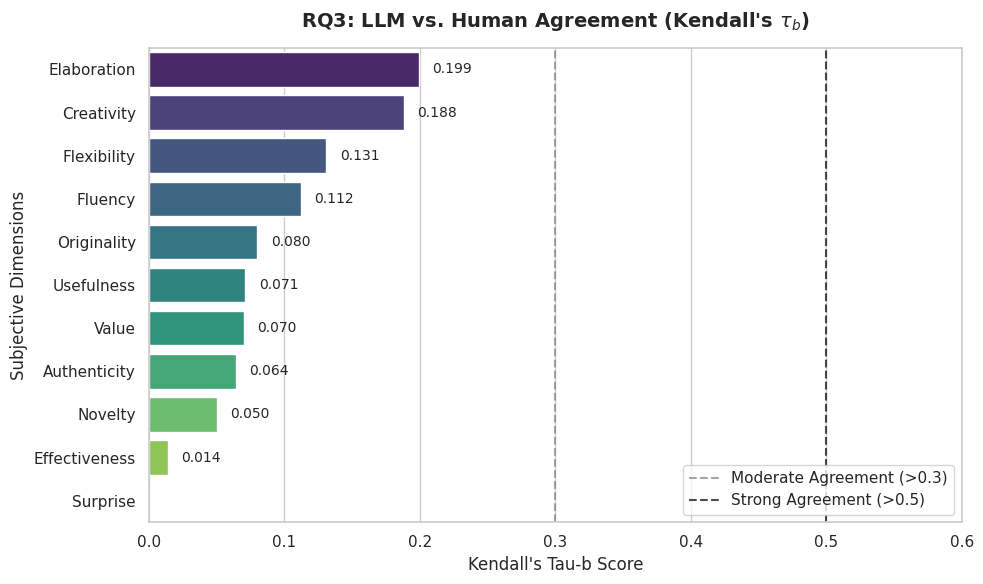

In [69]:
rq3_results = assess_llm_reliability(final_df, evaluation_metrics, human_prefix='human_', llm_prefix='llm_')
print(rq3_results)
rq3_results.to_csv('rq3_kendall_tau.csv', index=False)

plot_llm_reliability(rq3_results)

## **<u>RQ4:</u> _Distinguishability and Pattern Recognition_**

### **PCA**
Since these metrics operate on vastly different scales (e.g., Perplexity ranges from 10–100+, while Likert scores range from 1–5), we first standardize the data by applying a StandardScaler
to all features, then we use **Principal Component Analysis**, a linear dimensionality reduction technique, to project these high-dimensional normalized vectors into a 2D latent space.

In [70]:
def run_pca_analysis(df, feature_cols, group_col='source', human_label='human', ai_label='LLM'):
    """
    Runs PCA to project high-dimensional creativity metrics into a 2D latent space.
    """
    analysis_df = df.copy()
    
    # ensure all feature columns are numeric
    for col in feature_cols:
        analysis_df[col] = pd.to_numeric(analysis_df[col], errors='coerce')
        
    # drop rows with NaNs or -1s in any of the feature columns
    for col in feature_cols:
        analysis_df = analysis_df[(analysis_df[col].notna()) & (analysis_df[col] != -1)]
        
    print(f"Data remaining for PCA after cleaning: {len(analysis_df)} texts.")
    
    # extract Features (X) and Labels (y)
    X = analysis_df[feature_cols]
    y = analysis_df[group_col]
    
    # standardize the data to prevent Perplexity (scale 10-100) from dominating Likert scores (scale 1-5)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # fit the PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # add coordinates back to the dataframe for plotting
    analysis_df['PC1'] = X_pca[:, 0]
    analysis_df['PC2'] = X_pca[:, 1]
    
    # get the amount of variance explained by each component
    exp_var = pca.explained_variance_ratio_
    
    # --- Plot 1: The PCA Scatter Plot ---
    plt.figure(figsize=(10, 8))
    sns.set_theme(style="whitegrid")
    
    palette = {human_label: "#4C72B0", ai_label: "#55A868"}
    
    sns.scatterplot(
        x='PC1', y='PC2', 
        hue=group_col, 
        palette=palette,
        data=analysis_df, 
        alpha=0.7, 
        s=100,
        edgecolor='w',
        linewidth=0.5
    )
    
    plt.title('RQ4: PCA of Human vs. AI Creativity Profiles', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel(f'Principal Component 1 ({exp_var[0]*100:.1f}% Variance Explained)', fontsize=12)
    plt.ylabel(f'Principal Component 2 ({exp_var[1]*100:.1f}% Variance Explained)', fontsize=12)
    plt.legend(title='Author Source', loc='best')
    plt.tight_layout()
    plt.savefig('rq4_pca_scatter.pdf', format='pdf', dpi=300)
    plt.show()
    
    # --- Plot 2: Feature Loadings Heatmap (Bonus for Thesis) ---
    # This shows WHICH metrics are driving the separation
    loadings = pd.DataFrame(
        pca.components_.T, 
        columns=['PC1', 'PC2'], 
        index=feature_cols
    )
    
    plt.figure(figsize=(8, 10))
    sns.heatmap(loadings, annot=True, cmap="coolwarm", center=0, fmt=".2f", linewidths=0.5)
    plt.title('PCA Feature Loadings (What drives the components?)', fontsize=14, pad=15)
    plt.tight_layout()
    plt.savefig('rq4_pca_loadings.pdf', format='pdf', dpi=300)
    plt.show()
    
    return analysis_df, loadings, pca

Data remaining for PCA after cleaning: 200 texts.


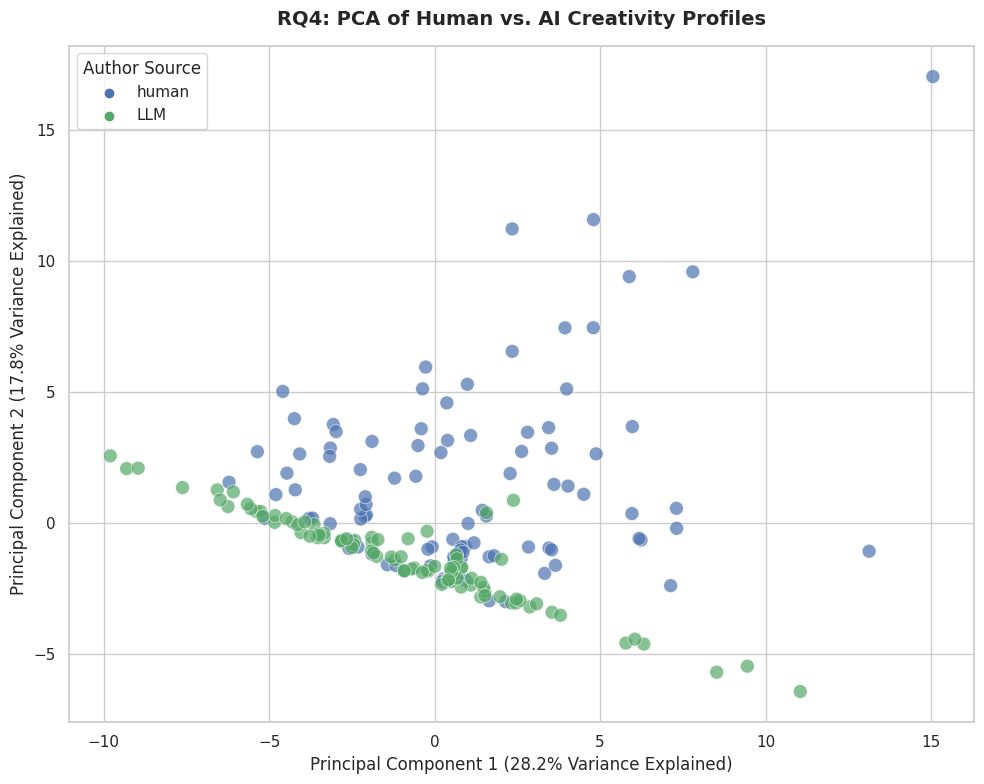

/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


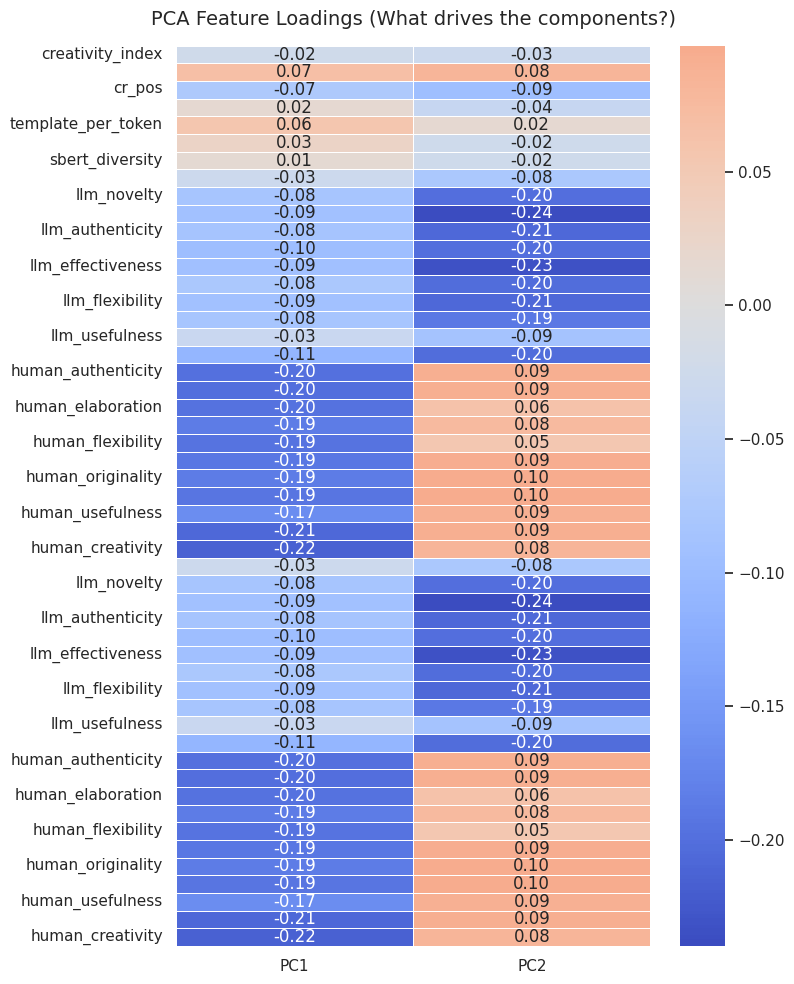

In [71]:
all_features = metrics + llm_as_a_judge_metrics_name + human_metrics_name
pca_df, feature_loadings, pca_model = run_pca_analysis(final_df, all_features, human_label='human', ai_label='LLM')

## **<u>Results review:</u> _Factor Analysis_**

### How many factors?
<u>Determine the number of ***factors*** to keep:</u>
- The **Kaiser criterion** states that you should use a number of factors equal to the <u>number of the **_eigenvalues_** of the correlation matrix that are greater than one</u>.
- The “**Scree test**” states that you should plot the **_eigenvalues_** of the correlation matrix in descending order, and then use <u>a number of factors equal to the number of eigenvalues that occur prior to the last major drop in eigenvalue magnitude</u>.


In [72]:
eigenvalues, eigenvectors = np.linalg.eig(corr)
kaiser_criterion = sum(eigenvalues > 1)
print("Factors by Kaiser criterion:", kaiser_criterion)

eigenvalues

Factors by Kaiser criterion: 5


array([6.61204781, 2.32477171, 1.55287247, 1.10104172, 1.06101367,
       0.92016919, 0.69617416, 0.06532818, 0.60517625, 0.52614186,
       0.47752255, 0.45898835, 0.19528211, 0.35455156, 0.22521533,
       0.3084272 , 0.2539502 , 0.26132569])

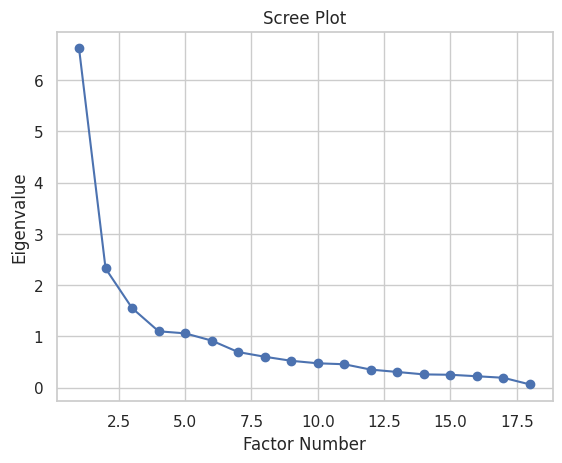

In [73]:
plt.plot(range(1, len(eigenvalues)+1), sorted(eigenvalues, reverse=True), marker='o')
plt.xlabel('Factor Number')
plt.ylabel('Eigenvalue')
plt.title('Scree Plot')
plt.show()

In [78]:
final_df

,source,creativity_index,perplexity,cr_pos,template_rate,template_per_token,ead,sbert_diversity,llm_surprise,llm_novelty,...,human_effectiveness,human_elaboration,human_fluency,human_flexibility,human_novelty,human_originality,human_surprise,human_usefulness,human_value,human_creativity
story_id,,,,,,,,,,,,,,,,,,,,,
1,human,6.193798,23.616358,5.892,0.479070,0.862016,0.442598,0.791343,5,5,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0
2,human,6.778182,11.088195,5.510,0.435737,0.783699,0.385521,0.813438,5,5,...,4.0,4.0,3.0,4.0,3.0,3.0,4.0,4.0,3.0,4.0
3,human,5.703476,19.137821,5.335,0.325540,0.611511,0.461685,0.794141,5,5,...,1.5,2.5,1.5,2.5,1.5,1.0,2.5,2.0,1.0,2.5
4,human,5.920341,10.507423,5.899,0.203498,0.368839,0.355574,0.717927,5,5,...,3.8,2.8,2.8,3.6,3.6,3.8,3.8,3.8,3.6,4.0
5,human,5.747521,11.037381,6.313,0.463992,0.847737,0.378316,0.851537,5,5,...,3.0,4.0,4.5,4.0,3.0,2.5,3.5,3.0,2.0,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196,LLM,6.252657,6.375385,6.066,0.556452,1.135484,0.489603,0.814894,5,4,...,4.0,4.5,4.0,4.0,3.0,2.5,2.0,3.5,4.0,3.5
197,LLM,6.563241,6.586911,5.573,0.379562,0.744526,0.518139,0.840376,5,5,...,2.5,3.5,3.5,3.0,3.0,3.5,2.5,3.0,3.0,3.5
198,LLM,5.968254,9.324446,5.524,0.509524,1.009524,0.494404,0.792120,5,5,...,3.0,3.5,4.0,4.0,3.0,3.5,3.5,4.5,3.5,2.5


In [80]:
data = final_df.copy()
data = data.iloc[:, 1:]
X = StandardScaler().fit_transform(data)
feature_names = list(data.columns)

In [81]:
feature_names

['creativity_index',
 'perplexity',
 'cr_pos',
 'template_rate',
 'template_per_token',
 'ead',
 'sbert_diversity',
 'llm_surprise',
 'llm_novelty',
 'llm_value',
 'llm_authenticity',
 'llm_originality',
 'llm_effectiveness',
 'llm_fluency',
 'llm_flexibility',
 'llm_elaboration',
 'llm_usefulness',
 'llm_creativity',
 'human_authenticity',
 'human_effectiveness',
 'human_elaboration',
 'human_fluency',
 'human_flexibility',
 'human_novelty',
 'human_originality',
 'human_surprise',
 'human_usefulness',
 'human_value',
 'human_creativity']



 PCA :

[[-0.03909654 -0.04806268  0.1051009 ]
 [ 0.11134562  0.12986935 -0.16402994]
 [-0.12457406 -0.1484641   0.3379226 ]
 [ 0.03381365 -0.05377027 -0.44102958]
 [ 0.09650441  0.02729295 -0.52597231]
 [ 0.06091838 -0.01723089 -0.47907489]
 [ 0.02105857 -0.03858294 -0.01807505]
 [-0.04249228 -0.10484695  0.00558011]
 [-0.12435485 -0.2754013   0.02605016]
 [-0.13441022 -0.32754291 -0.11731351]
 [-0.12341464 -0.28418273 -0.12606012]
 [-0.14212032 -0.27426311  0.09829627]
 [-0.13507177 -0.31534768 -0.11220403]
 [-0.10939353 -0.27481328 -0.20509869]
 [-0.13432552 -0.28408537  0.03873679]
 [-0.12479812 -0.26403166  0.07457012]
 [-0.04806083 -0.11762682 -0.12813294]
 [-0.15920461 -0.27155114  0.01500249]
 [-0.27158202  0.14047884 -0.10725547]
 [-0.27759898  0.14188793 -0.04231387]
 [-0.27398919  0.09497692 -0.05890876]
 [-0.25742201  0.11535663 -0.06720623]
 [-0.26819981  0.0893229  -0.06737657]
 [-0.26407328  0.14391985 -0.0136055 ]
 [-0.25640358  0.14856818 -0.00767512]
 [-0.26507067  

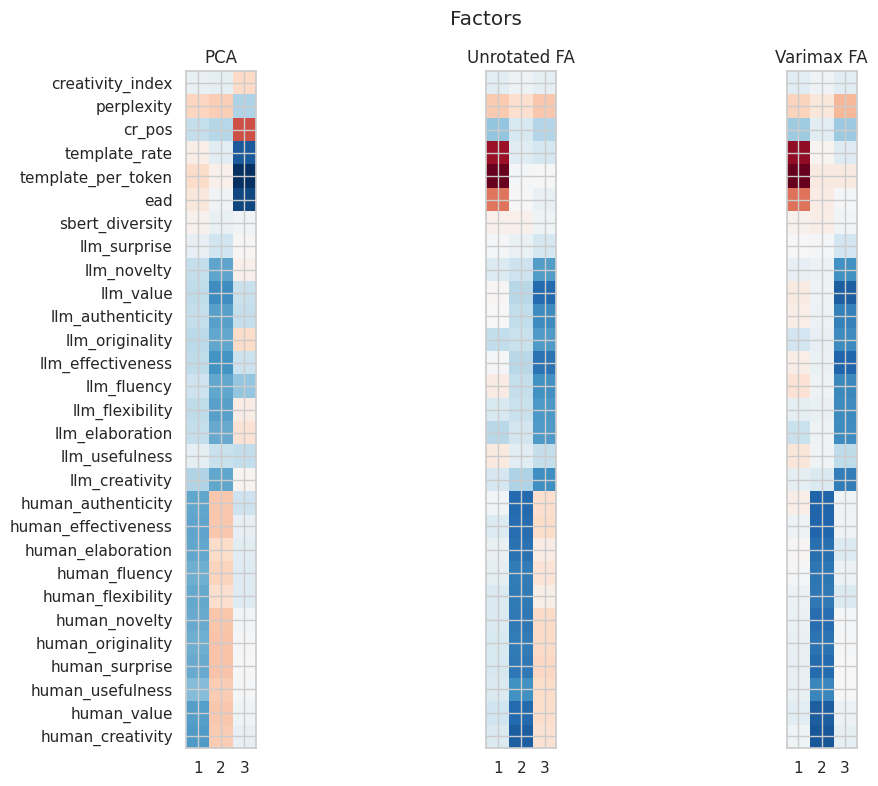

In [82]:
n_comps = 3

methods = [
    ("PCA", PCA()),
    ("Unrotated FA", FactorAnalysis()),
    ("Varimax FA", FactorAnalysis(rotation="varimax")),
]
fig, axes = plt.subplots(ncols=len(methods), figsize=(12, 8), sharey=True)

for ax, (method, fa) in zip(axes, methods):
    fa.set_params(n_components=n_comps)
    fa.fit(X)

    components = fa.components_.T
    print("\n\n %s :\n" % method)
    print(components)

    vmax = np.abs(components).max()
    ax.imshow(components, cmap="RdBu_r", vmax=vmax, vmin=-vmax)
    ax.set_yticks(np.arange(len(feature_names)))
    ax.set_yticklabels(feature_names)
    ax.set_title(str(method))
    ax.set_xticks(range(n_comps))
    ax.set_xticklabels([f"{i}" for i in range(1,n_comps+1)])
fig.suptitle("Factors")
plt.tight_layout()
plt.show()

<u>There might be these **three factors** underlying the metrics:</u>
1. **_Text structure_**
2. **_LLM-judged creativity_**
3. **_LLM-judged quality_**